In [ ]:
from google.colab import files
uploaded = files.upload()

Saving processed.cleveland.data to processed.cleveland.data
Saving processed.hungarian.data to processed.hungarian.data
Saving processed.switzerland.data to processed.switzerland.data
Saving processed.va.data to processed.va.data


In [ ]:
import pandas as pd
import numpy as np

# Define column names
col_names = ['age','sex','cp','trestbps','chol','fbs',
             'restecg','thalach','exang','oldpeak',
             'slope','ca','thal','target']

# Load all 4 files
df1 = pd.read_csv('processed.cleveland.data', names=col_names, na_values='?')
df2 = pd.read_csv('processed.hungarian.data', names=col_names, na_values='?')
df3 = pd.read_csv('processed.switzerland.data', names=col_names, na_values='?')
df4 = pd.read_csv('processed.va.data', names=col_names, na_values='?')

# Concat all
df = pd.concat([df1, df2, df3, df4], ignore_index=True)
print("Data awal:", df.shape)

# Remove duplicates
df = df.drop_duplicates()
print("Setelah hapus duplikat:", df.shape)

# Fill missing values with median
df = df.fillna(df.median())
print("Missing values:", df.isnull().sum().sum())

# Encode target to binary (0 = tidak sakit, 1 = sakit)
df['target'] = df['target'].apply(lambda x: 1 if x > 0 else 0)
print("\nDistribusi target:")
print(df['target'].value_counts())

Data awal: (920, 14)
Setelah hapus duplikat: (918, 14)
Missing values: 0

Distribusi target:
target
1    508
0    410
Name: count, dtype: int64


In [ ]:
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE

# Separate features and target
X = df.drop('target', axis=1)
y = df['target']

# Apply SMOTE to balance classes
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X, y)

print("Setelah SMOTE:", X_resampled.shape)
print("Target distribution:")
print(pd.Series(y_resampled).value_counts())

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_resampled, y_resampled, test_size=0.2, random_state=42, stratify=y_resampled)

print("\n✅ X_train:", X_train.shape)
print("✅ X_test:", X_test.shape)
print("✅ y_train:", y_train.shape)
print("✅ y_test:", y_test.shape)

Setelah SMOTE: (1016, 13)
Target distribution:
target
0    508
1    508
Name: count, dtype: int64

✅ X_train: (812, 13)
✅ X_test: (204, 13)
✅ y_train: (812,)
✅ y_test: (204,)


In [ ]:
from sklearn.ensemble import (
    BaggingClassifier,
    RandomForestClassifier,
    AdaBoostClassifier,
    GradientBoostingClassifier,
    HistGradientBoostingClassifier,
    ExtraTreesClassifier,
    StackingClassifier,
    VotingClassifier
)
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [ ]:
# Base estimator for Bagging and AdaBoost
base_dt = DecisionTreeClassifier(max_depth=5, random_state=42)

# Dictionary of ensemble models
ensemble_models = {}

print("=" * 50)
print("TRAINING ENSEMBLE MODELS")
print("=" * 50)

# 1. Bagging
print("\n1. Training Bagging...")
bagging = BaggingClassifier(estimator=base_dt, n_estimators=50, random_state=42)
bagging.fit(X_train, y_train)
ensemble_models['Bagging'] = bagging
print("   ✅ Bagging done!")

# 2. Random Forest
print("\n2. Training Random Forest...")
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
ensemble_models['Random Forest'] = rf
print("   ✅ Random Forest done!")

# 3. AdaBoost
print("\n3. Training AdaBoost...")
adaboost = AdaBoostClassifier(estimator=base_dt, n_estimators=50, random_state=42, algorithm='SAMME')
adaboost.fit(X_train, y_train)
ensemble_models['AdaBoost'] = adaboost
print("   ✅ AdaBoost done!")

# 4. Gradient Boosting
print("\n4. Training Gradient Boosting...")
gb = GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=42)
gb.fit(X_train, y_train)
ensemble_models['Gradient Boosting'] = gb
print("   ✅ Gradient Boosting done!")

# 5. Hist Gradient Boosting
print("\n5. Training Hist Gradient Boosting...")
hgb = HistGradientBoostingClassifier(max_iter=100, max_depth=5, random_state=42)
hgb.fit(X_train, y_train)
ensemble_models['Hist Gradient Boosting'] = hgb
print("   ✅ Hist Gradient Boosting done!")

# 6. Extra Trees
print("\n6. Training Extra Trees...")
et = ExtraTreesClassifier(n_estimators=100, max_depth=10, random_state=42)
et.fit(X_train, y_train)
ensemble_models['Extra Trees'] = et
print("   ✅ Extra Trees done!")

print("\n" + "=" * 50)
print("6 ensemble models trained!")
print("=" * 50)

TRAINING ENSEMBLE MODELS

1. Training Bagging...
   ✅ Bagging done!

2. Training Random Forest...
   ✅ Random Forest done!

3. Training AdaBoost...


/usr/local/lib/python3.12/dist-packages/sklearn/ensemble/_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


   ✅ AdaBoost done!

4. Training Gradient Boosting...
   ✅ Gradient Boosting done!

5. Training Hist Gradient Boosting...
   ✅ Hist Gradient Boosting done!

6. Training Extra Trees...
   ✅ Extra Trees done!

6 ensemble models trained!


In [ ]:
print("\n7. Training Stacking...")

# Base models for stacking
estimators = [
    ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
    ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
    ('et', ExtraTreesClassifier(n_estimators=50, random_state=42))
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(),
    cv=5
)

stacking.fit(X_train, y_train)
ensemble_models['Stacking'] = stacking
print("   ✅ Stacking done!")


7. Training Stacking...
   ✅ Stacking done!


In [ ]:
print("\n8. Training Voting...")

voting = VotingClassifier(
    estimators=[
        ('rf', RandomForestClassifier(n_estimators=50, random_state=42)),
        ('gb', GradientBoostingClassifier(n_estimators=50, random_state=42)),
        ('et', ExtraTreesClassifier(n_estimators=50, random_state=42))
    ],
    voting='soft'
)

voting.fit(X_train, y_train)
ensemble_models['Voting'] = voting
print("   ✅ Voting done!")

print("\n🎉 ALL 8 ENSEMBLE MODELS TRAINED!")


8. Training Voting...
   ✅ Voting done!

🎉 ALL 8 ENSEMBLE MODELS TRAINED!


In [ ]:
results = []

print("\n" + "=" * 70)
print("EVALUATING ALL ENSEMBLE MODELS")
print("=" * 70)

for name, model in ensemble_models.items():
    # Test prediction
    y_pred = model.predict(X_test)
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc_test = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_pred_proba)

    # Train prediction (check overfitting)
    y_train_pred = model.predict(X_train)
    acc_train = accuracy_score(y_train, y_train_pred)

    results.append({
        'Model': name,
        'Akurasi Test (%)': round(acc_test * 100, 2),
        'Akurasi Train (%)': round(acc_train * 100, 2),
        'Selisih (%)': round(abs(acc_train - acc_test) * 100, 2),
        'F1-Score': round(f1, 4),
        'AUC': round(auc, 4)
    })

df_results = pd.DataFrame(results)
df_results = df_results.sort_values('Akurasi Test (%)', ascending=False)

print("\n=== HASIL EVALUASI 8 ENSEMBLE METHODS ===\n")
print(df_results.to_string(index=False))


EVALUATING ALL ENSEMBLE MODELS

=== HASIL EVALUASI 8 ENSEMBLE METHODS ===

                 Model  Akurasi Test (%)  Akurasi Train (%)  Selisih (%)  F1-Score    AUC
           Extra Trees             84.31              95.07        10.76    0.8367 0.9145
     Gradient Boosting             83.33              99.75        16.42    0.8265 0.8898
                Voting             81.86             100.00        18.14    0.8063 0.9105
              AdaBoost             81.86             100.00        18.14    0.8122 0.8657
              Stacking             81.37             100.00        18.63    0.8000 0.9114
         Random Forest             79.90              98.03        18.13    0.7853 0.8957
Hist Gradient Boosting             79.90              96.06        16.16    0.7897 0.8912
               Bagging             78.92              89.29        10.36    0.7749 0.8874


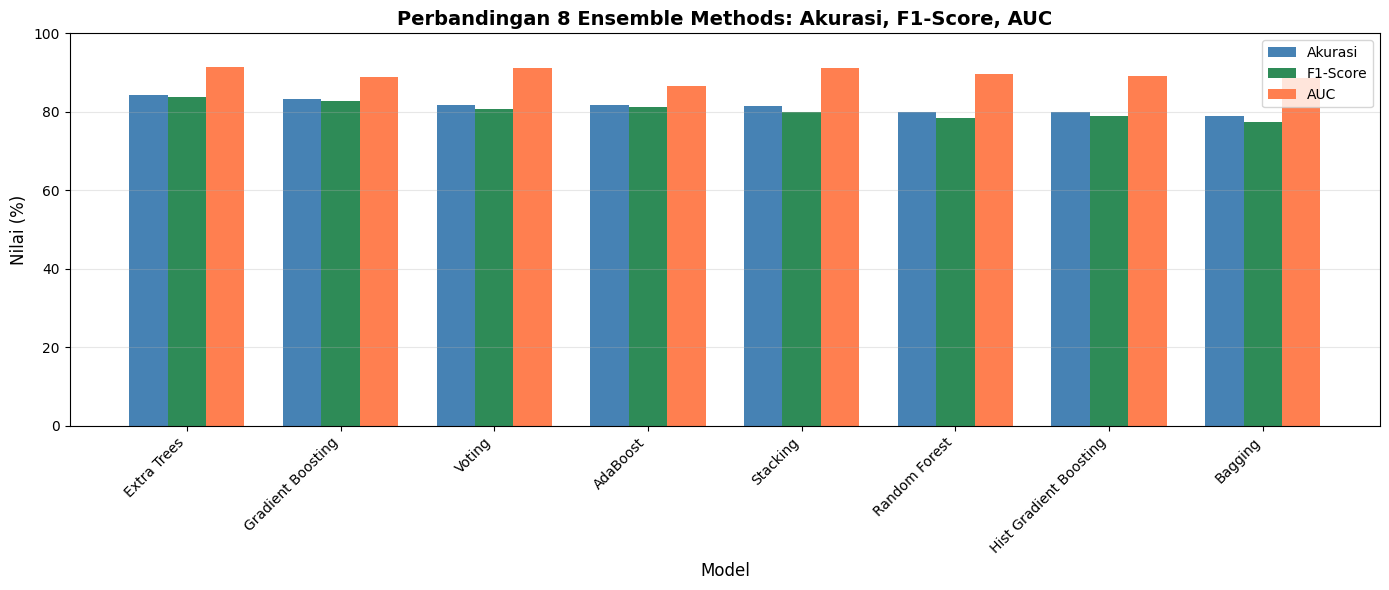

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

models = df_results['Model'].tolist()
acc_test = df_results['Akurasi Test (%)'].tolist()
f1_scores = [x * 100 for x in df_results['F1-Score'].tolist()]
auc_scores = [x * 100 for x in df_results['AUC'].tolist()]

x = np.arange(len(models))
width = 0.25

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width, acc_test, width, label='Akurasi', color='steelblue')
bars2 = ax.bar(x, f1_scores, width, label='F1-Score', color='seagreen')
bars3 = ax.bar(x + width, auc_scores, width, label='AUC', color='coral')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Nilai (%)', fontsize=12)
ax.set_title('Perbandingan 8 Ensemble Methods: Akurasi, F1-Score, AUC',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 100)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('perbandingan_8_ensemble.png', dpi=100, bbox_inches='tight')
plt.show()

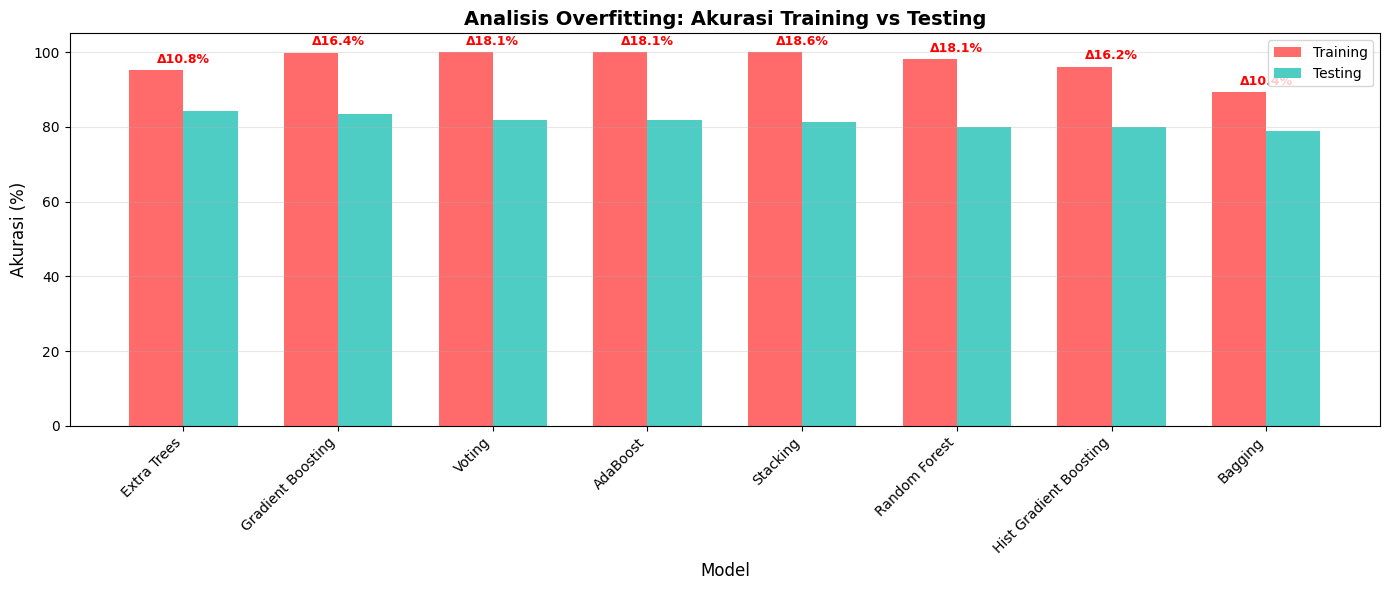

In [ ]:
models = df_results['Model'].tolist()
acc_train = df_results['Akurasi Train (%)'].tolist()
acc_test = df_results['Akurasi Test (%)'].tolist()

x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
bars1 = ax.bar(x - width/2, acc_train, width, label='Training', color='#FF6B6B')
bars2 = ax.bar(x + width/2, acc_test, width, label='Testing', color='#4ECDC4')

ax.set_xlabel('Model', fontsize=12)
ax.set_ylabel('Akurasi (%)', fontsize=12)
ax.set_title('Analisis Overfitting: Akurasi Training vs Testing',
             fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=45, ha='right')
ax.legend()
ax.set_ylim(0, 105)
ax.grid(axis='y', alpha=0.3)

# Tambah label selisih
for i, (train, test) in enumerate(zip(acc_train, acc_test)):
    selisih = abs(train - test)
    ax.text(i, max(train, test) + 2, f'Δ{selisih:.1f}%',
            ha='center', fontsize=9, fontweight='bold', color='red')

plt.tight_layout()
plt.savefig('overfitting_analysis.png', dpi=100, bbox_inches='tight')
plt.show()

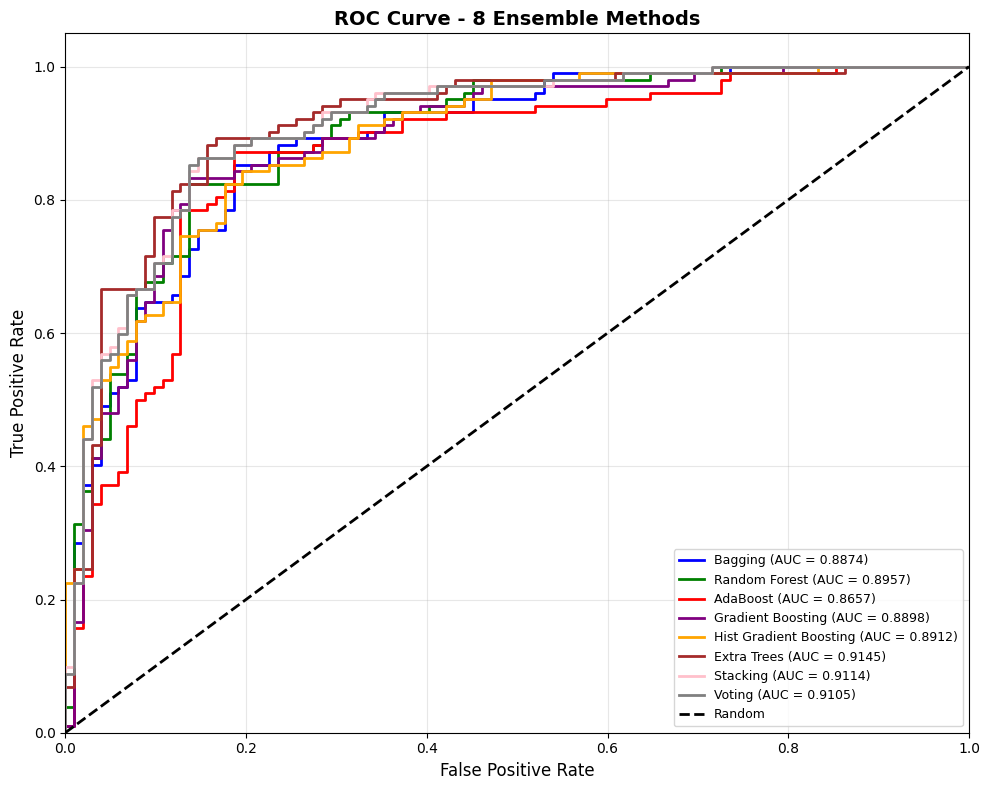

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(10, 8))

colors = ['blue', 'green', 'red', 'purple', 'orange', 'brown', 'pink', 'gray']

for (name, model), color in zip(ensemble_models.items(), colors):
    y_pred_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    roc_auc = auc(fpr, tpr)

    plt.plot(fpr, tpr, color=color, lw=2,
             label=f'{name} (AUC = {roc_auc:.4f})')

plt.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random')

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve - 8 Ensemble Methods', fontsize=14, fontweight='bold')
plt.legend(loc="lower right", fontsize=9)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_8_ensemble.png', dpi=100, bbox_inches='tight')
plt.show()